In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib


In [2]:
data = np.load("./processed_data/crop_data.npz")
Xtrain = data["Xtrain"]
Ytrain = data["Ytrain"]
Xtest = data["Xtest"]
Ytest = data["Ytest"]
Xtrain.shape

(400, 5)

In [3]:
random_forest = RandomForestClassifier(n_estimators=15, max_depth=8, random_state=0)
random_forest.fit(Xtrain, Ytrain)

RandomForestClassifier(max_depth=8, n_estimators=15, random_state=0)

In [4]:
rf_predictions = random_forest.predict(Xtest)

In [5]:
rf_accuracy = accuracy_score(Ytest, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.9802


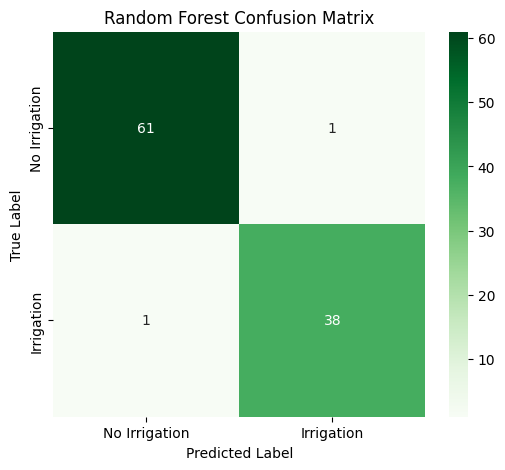

In [6]:
# Compute Confusion Matrix
cm_rf = confusion_matrix(Ytest, rf_predictions)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=["No Irrigation", "Irrigation"], yticklabels=["No Irrigation", "Irrigation"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [12]:
# save the model
joblib.dump(random_forest, "../model/random_forest_model.joblib")

['../model/random_forest_model.joblib']